
# Task 1

In [ ]:
# استيراد المكتبات
import pandas as pd
import numpy as np

# رفع الملف من جهازك
from google.colab import files
uploaded = files.upload()  # اختَر ملف GlobalTemperatures.csv

# قراءة الملف
df = pd.read_csv('GlobalTemperatures.csv')

# عرض أول 5 صفوف
print(" أول 5 صفوف من البيانات:")
print(df.head())

# معلومات الأعمدة والأنواع
print("\nℹ معلومات عن هيكل البيانات:")
print(df.info())

# وصف إحصائي
print("\nوصف إحصائي للبيانات الرقمية:")
print(df.describe())

# القيم المفقودة
print("\n عدد القيم المفقودة في كل عمود:")
print(df.isnull().sum())

# الصفوف المكررة
print("\n عدد الصفوف المكررة:")
print(df.duplicated().sum())

Saving GlobalTemperatures.csv to GlobalTemperatures (1).csv
 أول 5 صفوف من البيانات:
           dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
0  1750-01-01                   3.034                              3.574   
1  1750-02-01                   3.083                              3.702   
2  1750-03-01                   5.626                              3.076   
3  1750-04-01                   8.490                              2.451   
4  1750-05-01                  11.573                              2.072   

   LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
0                 NaN                            NaN                 NaN   
1                 NaN                            NaN                 NaN   
2                 NaN                            NaN                 NaN   
3                 NaN                            NaN                 NaN   
4                 NaN                            NaN                 NaN   

 

#Task 2


In [ ]:
# 1. تحويل عمود التاريخ dt إلى تنسيق datetime
df['dt'] = pd.to_datetime(df['dt'])

# التأكد من التحويل
print(" نوع العمود 'dt' بعد التحويل:", df['dt'].dtype)

# 2. حذف الصفوف التي تحتوي على قيم مفقودة في العمود الأساسي
df_cleaned = df.dropna(subset=['LandAverageTemperature'])

# عرض عدد الصفوف بعد الحذف
print(" عدد الصفوف قبل التنظيف:", len(df))
print(" عدد الصفوف بعد التنظيف:", len(df_cleaned))

# 3. إعادة ضبط الفهرس (اختياري)
df_cleaned.reset_index(drop=True, inplace=True)

 نوع العمود 'dt' بعد التحويل: datetime64[ns]
 عدد الصفوف قبل التنظيف: 3192
 عدد الصفوف بعد التنظيف: 3180


# task 3

<ipython-input-4-1235806847>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Year'] = df_cleaned['dt'].dt.year


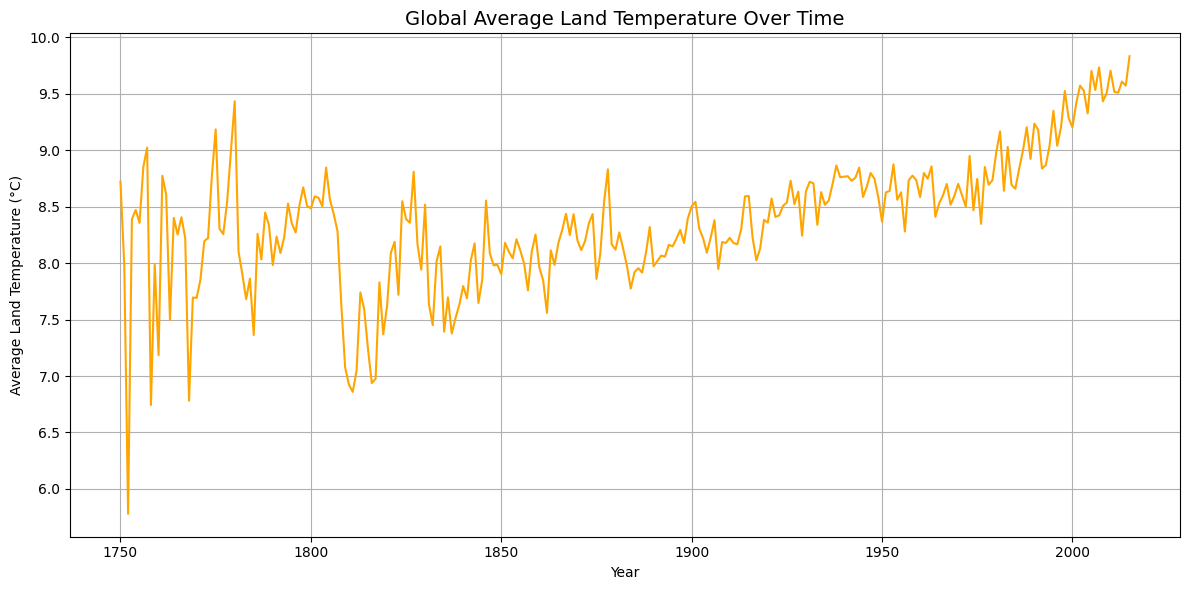

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# تحويل عمود التاريخ إلى تنسيق datetime
df['dt'] = pd.to_datetime(df['dt'])

# حذف الصفوف التي تحتوي على قيم مفقودة في عمود درجة الحرارة الأساسية
df_cleaned = df.dropna(subset=['LandAverageTemperature'])
df_cleaned.reset_index(drop=True, inplace=True)

# استخراج السنة من العمود dt وإنشاء عمود جديد اسمه Year
df_cleaned['Year'] = df_cleaned['dt'].dt.year

# تجميع البيانات حسب السنة وحساب متوسط درجة الحرارة لكل سنة
annual_temp = df_cleaned.groupby('Year')['LandAverageTemperature'].mean().reset_index()

# رسم المخطط الخطي لعرض تغير درجات الحرارة عبر الزمن
plt.figure(figsize=(12, 6))
plt.plot(annual_temp['Year'], annual_temp['LandAverageTemperature'], color='orange')

# إعداد عنوان ومكونات الرسم البياني
plt.title('Global Average Land Temperature Over Time', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Land Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Task 4

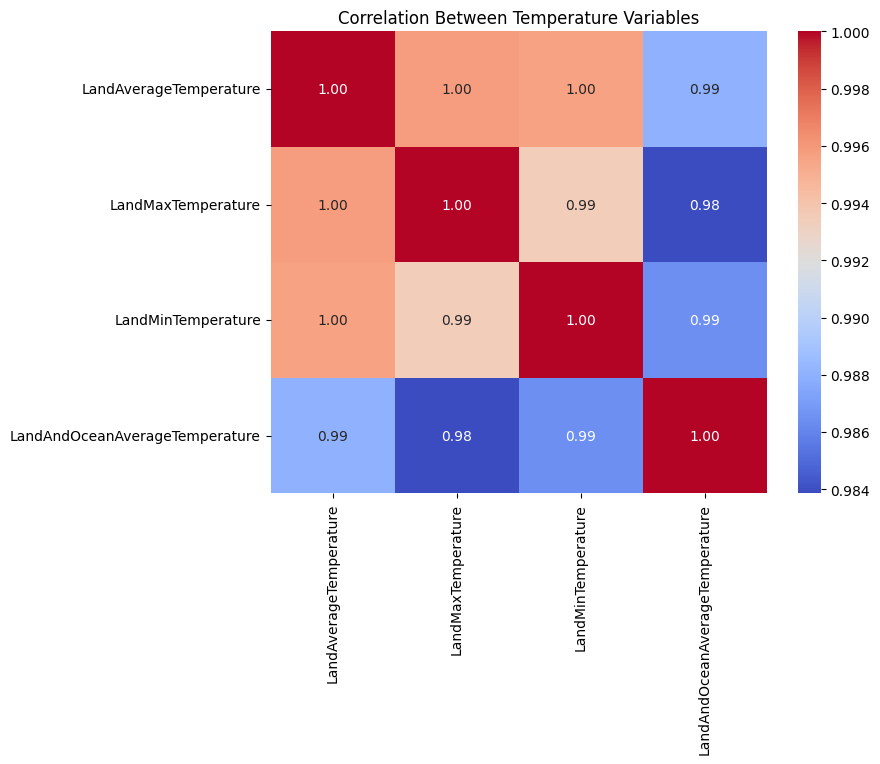

In [ ]:
import seaborn as sns

# حذف الصفوف التي تحتوي على قيم مفقودة في الأعمدة المستخدمة
df_corr = df_cleaned[['LandAverageTemperature', 'LandMaxTemperature',
                      'LandMinTemperature', 'LandAndOceanAverageTemperature']].dropna()

# حساب معامل الترابط (Correlation Matrix)
correlation_matrix = df_corr.corr()

# عرض مصفوفة الترابط باستخدام heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Temperature Variables')
plt.show()

# Top 10 Countries with the Highest Increase in Average Temperature (1960–2015)

Saving GlobalLandTemperaturesByCountry.csv to GlobalLandTemperaturesByCountry.csv


<ipython-input-6-3531773582>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_country['Year'] = df_country['dt'].dt.year


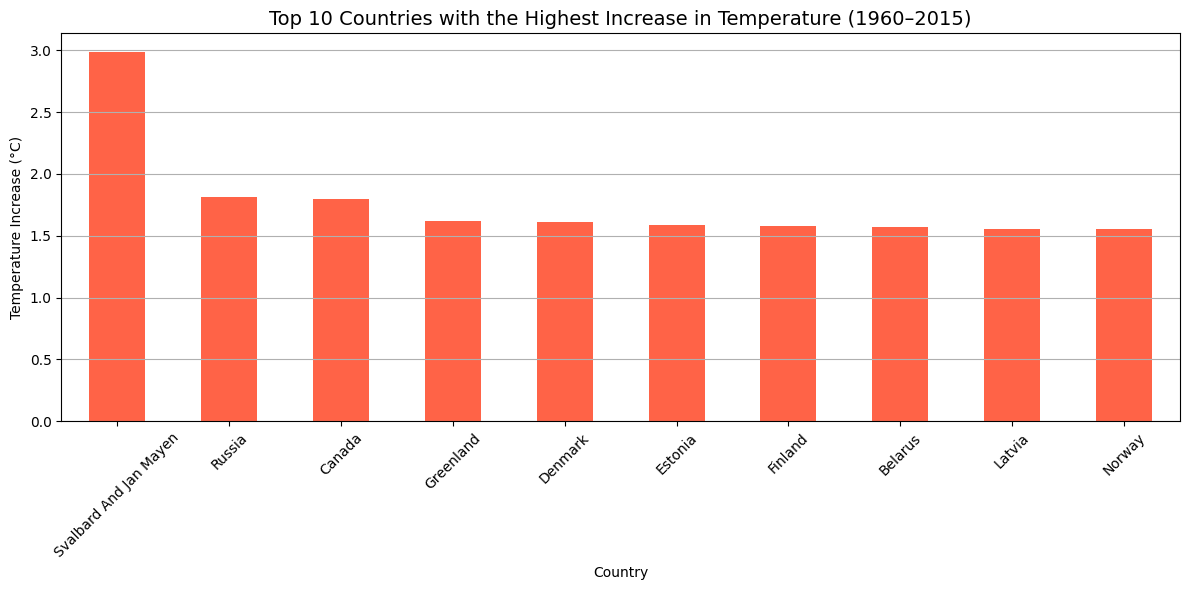

In [ ]:

from google.colab import files
uploaded = files.upload()  # اختر ملف GlobalLandTemperaturesByCountry.csv

#  استيراد المكتبات
import pandas as pd
import matplotlib.pyplot as plt

# قراءة البيانات
df_country = pd.read_csv('GlobalLandTemperaturesByCountry.csv')

#  تحويل عمود التاريخ
df_country['dt'] = pd.to_datetime(df_country['dt'])

#  حذف الصفوف التي تحتوي على قيم مفقودة في درجة الحرارة
df_country = df_country.dropna(subset=['AverageTemperature'])

#  استخراج السنة فقط من التاريخ
df_country['Year'] = df_country['dt'].dt.year

#  تصفية البيانات للفترة بين 1960 و2015
df_filtered = df_country[(df_country['Year'] >= 1960) & (df_country['Year'] <= 2015)]

#  حساب المتوسط السنوي لكل دولة
annual_temp = df_filtered.groupby(['Country', 'Year'])['AverageTemperature'].mean().reset_index()

#  حساب متوسط درجات الحرارة لكل دولة في فترتين:
old_avg = annual_temp[annual_temp['Year'].between(1960, 1970)].groupby('Country')['AverageTemperature'].mean()
new_avg = annual_temp[annual_temp['Year'].between(2005, 2015)].groupby('Country')['AverageTemperature'].mean()

#  حساب الفرق بين الفترتين
temp_diff = (new_avg - old_avg).dropna().sort_values(ascending=False)

#  استخراج أعلى 10 دول ارتفعت فيها الحرارة
top10 = temp_diff.head(10)

# رسم النتائج
plt.figure(figsize=(12, 6))
top10.plot(kind='bar', color='tomato')
plt.title('Top 10 Countries with the Highest Increase in Temperature (1960–2015)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Temperature Increase (°C)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Heatmap of Average Temperature by Country


In [ ]:
# تثبيت plotly (إذا ما كان مثبت)
!pip install plotly --quiet

import pandas as pd
import plotly.express as px

# تحميل الملف
df_country = pd.read_csv('GlobalLandTemperaturesByCountry.csv')

# تحويل التاريخ
df_country['dt'] = pd.to_datetime(df_country['dt'])

# حذف القيم المفقودة
df_country = df_country.dropna(subset=['AverageTemperature'])

# استخراج السنة
df_country['Year'] = df_country['dt'].dt.year

# اختيار فترة معينة (مثلاً من سنة 2000 وما بعد)
df_recent = df_country[df_country['Year'] >= 2000]

# حساب المتوسط لكل دولة في الفترة المحددة
country_avg = df_recent.groupby('Country')['AverageTemperature'].mean().reset_index()

# حذف الدول غير المعروفة
country_avg = country_avg[country_avg['Country'] != 'Antarctica']

# رسم خريطة حرارية باستخدام plotly
fig = px.choropleth(country_avg,
                    locations="Country",
                    locationmode="country names",
                    color="AverageTemperature",
                    color_continuous_scale="YlOrRd",
                    title="Average Temperature by Country (2000–2023)",
                    labels={'AverageTemperature': 'Avg Temp (°C)'}
)

fig.show()

<ipython-input-7-900266990>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_country['Year'] = df_country['dt'].dt.year


# Top 10 Hottest Cities in the World

In [ ]:
from google.colab import files
uploaded = files.upload()
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Saving GlobalLandTemperaturesByCity.csv to GlobalLandTemperaturesByCity.csv


NameError: name 'top10_cities' is not defined

<Figure size 1200x600 with 0 Axes>

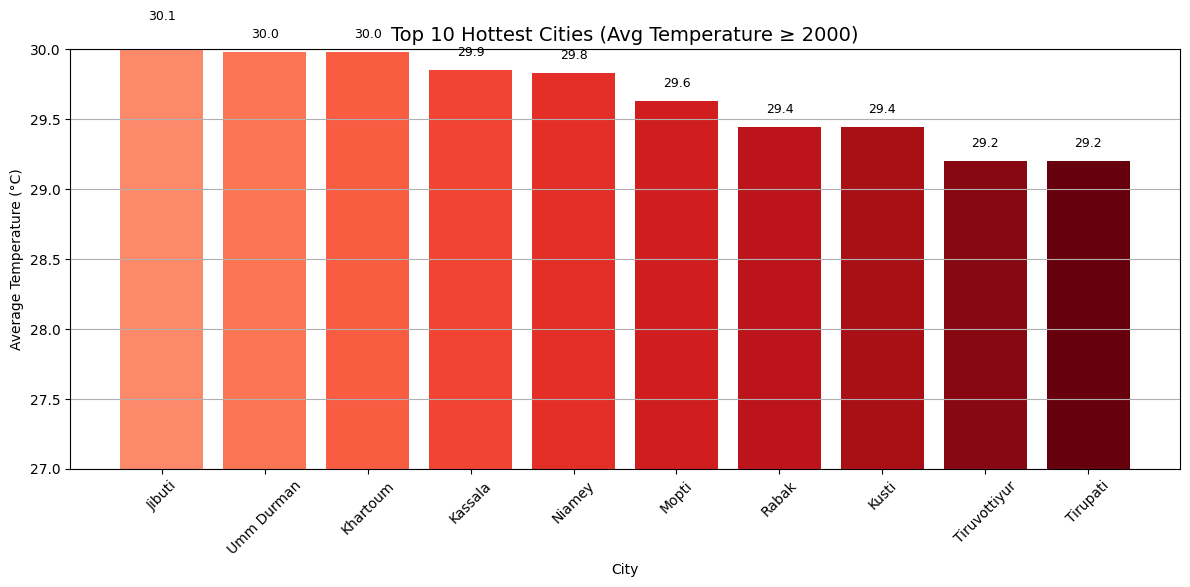

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# قراءة ملف المدن
df_city = pd.read_csv('GlobalLandTemperaturesByCity.csv')

# تحويل التاريخ إلى datetime
df_city['dt'] = pd.to_datetime(df_city['dt'])

# فلترة السنوات >= 2000 وحذف القيم المفقودة
df_city_recent = df_city[df_city['dt'].dt.year >= 2000]
df_city_recent = df_city_recent.dropna(subset=['AverageTemperature'])

# حساب أعلى 10 مدن حسب متوسط الحرارة
top10_cities = df_city_recent.groupby('City')['AverageTemperature'].mean().sort_values(ascending=False).head(10).reset_index()

# رسم الأعمدة
plt.figure(figsize=(12, 6))
colors = plt.cm.Reds(np.linspace(0.4, 1, 10))
plt.bar(top10_cities['City'], top10_cities['AverageTemperature'], color=colors)

# كتابة القيم فوق الأعمدة
for i, val in enumerate(top10_cities['AverageTemperature']):
    plt.text(i, val + 0.1, f"{val:.1f}", ha='center', fontsize=9)

# إعدادات الشكل
plt.title('Top 10 Hottest Cities (Avg Temperature ≥ 2000)', fontsize=14)
plt.xlabel('City')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.ylim(27, 30)  # حسب قيمك
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Seasonal Temperature Analysis for a Selected City (Summer vs Winter)

<ipython-input-6-2267205806>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='AverageTemperature', data=df_filtered, palette='coolwarm')


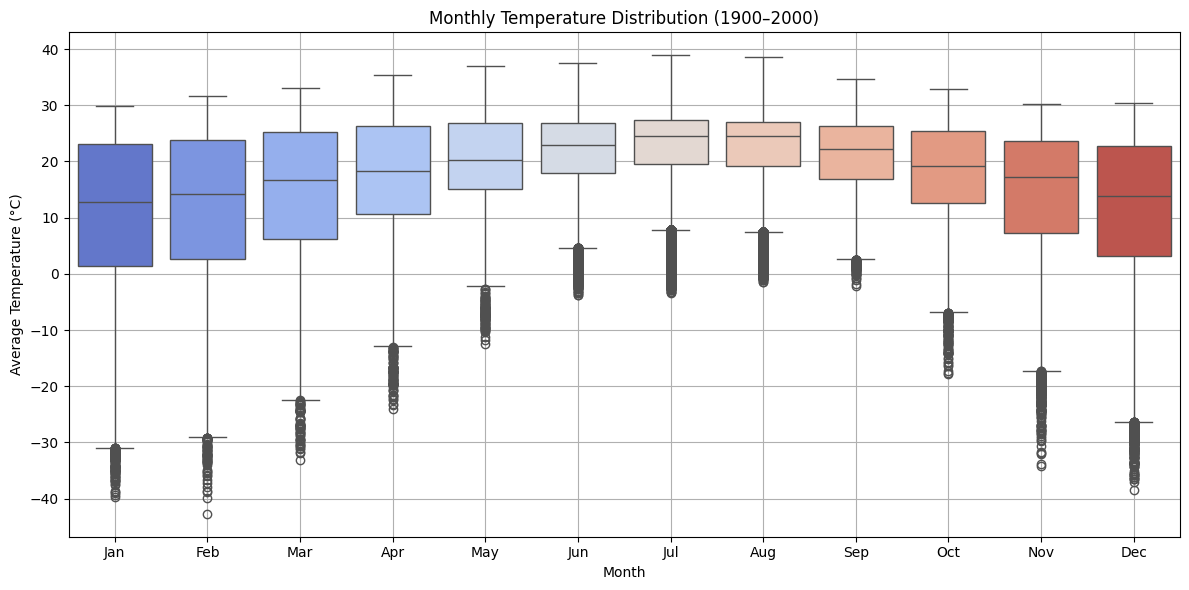

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# قراءة ملف المدن (بعد رفعه)
df_cities = pd.read_csv('GlobalLandTemperaturesByCity.csv')

# تحويل التاريخ
df_cities['dt'] = pd.to_datetime(df_cities['dt'])

# حذف الصفوف التي تحتوي على درجات حرارة مفقودة
df_cities = df_cities.dropna(subset=['AverageTemperature'])

# استخراج السنة والشهر
df_cities['Year'] = df_cities['dt'].dt.year
df_cities['Month'] = df_cities['dt'].dt.month

# تصفية الفترة من 1900 إلى 2000
df_filtered = df_cities[(df_cities['Year'] >= 1900) & (df_cities['Year'] <= 2000)]

# رسم Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='AverageTemperature', data=df_filtered, palette='coolwarm')
plt.title('Monthly Temperature Distribution (1900–2000)')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(ticks=range(0, 12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Top 10 Countries by Temperature Trend Slope (1900–2013)

<ipython-input-15-310011836>:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-15-310011836>:33: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



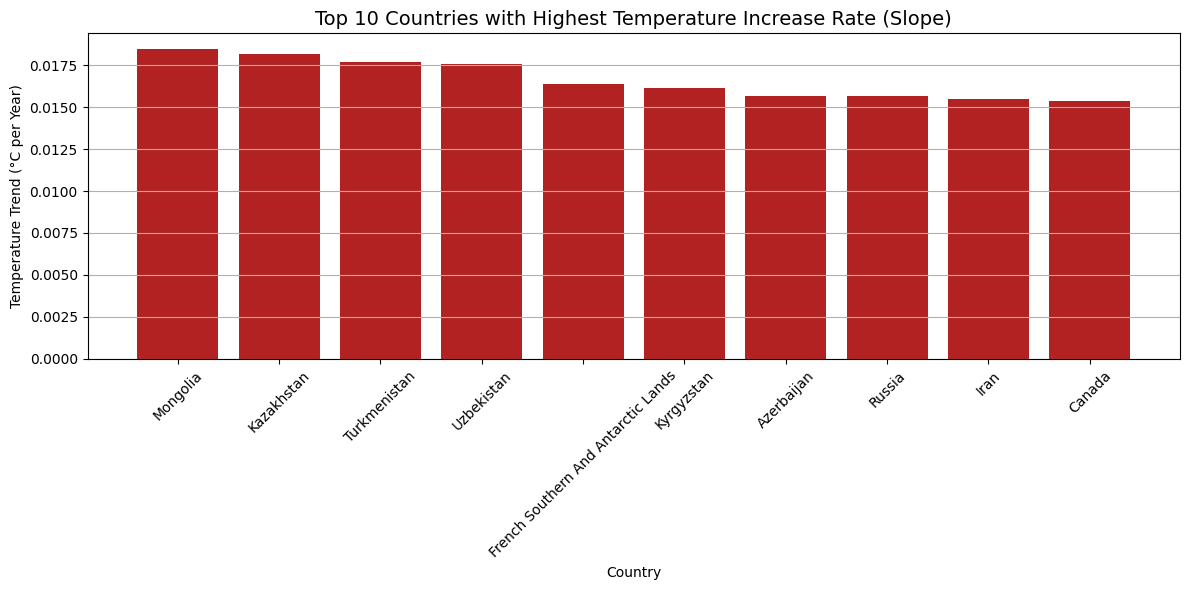

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# قراءة الملف
df_country = pd.read_csv('GlobalLandTemperaturesByCountry.csv')

# تحويل التاريخ
df_country['dt'] = pd.to_datetime(df_country['dt'])

# حذف القيم المفقودة
df_country = df_country.dropna(subset=['AverageTemperature'])

# استخراج السنة
df_country['Year'] = df_country['dt'].dt.year

# تصفية البيانات للفترة من 1900 إلى 2013
df_filtered = df_country[(df_country['Year'] >= 1900) & (df_country['Year'] <= 2013)]

# تجميع متوسط درجة الحرارة السنوي لكل دولة
annual_temp = df_filtered.groupby(['Country', 'Year'])['AverageTemperature'].mean().reset_index()

# حساب معدل الزيادة (slope) لكل دولة
def compute_slope(group):
    years = group['Year']
    temps = group['AverageTemperature']
    if len(years.unique()) >= 30:  # فقط الدول اللي عندها بيانات كافية
        slope, intercept = np.polyfit(years, temps, 1)
        return slope
    else:
        return np.nan

slope_df = annual_temp.groupby('Country').apply(compute_slope).reset_index()
slope_df.columns = ['Country', 'Temp_Slope']
slope_df = slope_df.dropna().sort_values(by='Temp_Slope', ascending=False)

# عرض أعلى 10 دول بمعدل ارتفاع
top10_slopes = slope_df.head(10)

# رسم النتائج
plt.figure(figsize=(12, 6))
plt.bar(top10_slopes['Country'], top10_slopes['Temp_Slope'], color='firebrick')
plt.title('Top 10 Countries with Highest Temperature Increase Rate (Slope)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Temperature Trend (°C per Year)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# استيراد المكتبات
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")

# تحميل الملفات
from google.colab import files
uploaded = files.upload()

# قراءة الملفات
co2_df = pd.read_csv("co2_emission.csv")
sea_df = pd.read_csv("Global_sea_level_rise.csv")
temp_df = pd.read_csv("GlobalTemperatures.csv")



Saving co2_emission.csv to co2_emission (6).csv
Saving Global_sea_level_rise.csv to Global_sea_level_rise (5).csv
Saving GlobalTemperatures.csv to GlobalTemperatures (4).csv


In [ ]:
# قراءة ملفات CSV إلى DataFrames
co2_df = pd.read_csv("co2_emission.csv")
sea_df = pd.read_csv("Global_sea_level_rise.csv")
temp_df = pd.read_csv("GlobalTemperatures.csv")


In [ ]:
print(" CO2 columns:", co2_df.columns.tolist())
print(" Sea Level columns:", sea_df.columns.tolist())
print(" Temperature columns:", temp_df.columns.tolist())

 CO2 columns: ['Entity', 'Code', 'Year', 'Annual CO₂ emissions (tonnes )']
 Sea Level columns: ['year', 'date', 'mmfrom1993-2008average']
 Temperature columns: ['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty']


In [ ]:
# استخدام بيانات 'World' فقط من جدول CO2
co2_filtered = co2_df[co2_df['Entity'] == 'World']

# اختيار السنة والانبعاثات
co2_filtered = co2_filtered[['Year', 'Annual CO₂ emissions (tonnes )']]

# إعادة تسمية العمود لتسهيل الاستخدام
co2_filtered.rename(columns={'Annual CO₂ emissions (tonnes )': 'CO2_Emissions'}, inplace=True)

In [ ]:
# اختيار السنة ومستوى سطح البحر
sea_df_clean = sea_df[['year', 'mmfrom1993-2008average']].copy()

# إعادة تسمية الأعمدة
sea_df_clean.rename(columns={
    'year': 'Year',
    'mmfrom1993-2008average': 'Sea_Level'
}, inplace=True)

In [ ]:
# تحويل عمود التاريخ إلى datetime
temp_df['dt'] = pd.to_datetime(temp_df['dt'])

# استخراج السنة
temp_df['Year'] = temp_df['dt'].dt.year

# تصفية البيانات من سنة 1900 فما فوق
temp_df = temp_df[temp_df['Year'] >= 1900]

# حساب المتوسط السنوي لدرجات الحرارة
temp_clean = temp_df[['Year', 'LandAverageTemperature']].groupby('Year').mean().reset_index()

# إعادة التسمية
temp_clean.rename(columns={'LandAverageTemperature': 'AverageTemperature'}, inplace=True)

In [ ]:
# دمج الحرارة مع انبعاثات CO2
merged = pd.merge(temp_clean, co2_filtered, on='Year', how='inner')

# دمج الناتج مع مستوى سطح البحر
merged = pd.merge(merged, sea_df_clean, on='Year', how='inner')

# حذف الصفوف التي تحتوي على قيم ناقصة
merged.dropna(inplace=True)

# عرض أول 5 صفوف للتأكد
merged.head()


,Year,AverageTemperature,CO2_Emissions,Sea_Level
0,1900,8.501583,1.953308e+09,-152.047396
1,1901,8.541917,2.017970e+09,-156.547396
2,1902,8.304417,2.069097e+09,-153.714063
3,1903,8.220167,2.257269e+09,-138.347396
4,1904,8.090917,2.281225e+09,-152.247396


from matplotlib import pyplot as plt
_df_16['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_17['Year'].plot(kind='hist', bins=20, title='Year')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_18['AverageTemperature'].plot(kind='hist', bins=20, title='AverageTemperature')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_19['CO2_Emissions'].plot(kind='hist', bins=20, title='CO2_Emissions')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['AverageTemperature']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_27.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('AverageTemperature')

from matplotlib import pyplot as plt
_df_28['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_29['Year'].plot(kind='line', figsize=(8, 4), title='Year')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_30['AverageTemperature'].plot(kind='line', figsize=(8, 4), title='AverageTemperature')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_31['CO2_Emissions'].plot(kind='line', figsize=(8, 4), title='CO2_Emissions')
plt.gca().spines[['top', 'right']].set_visible(False)

# CO₂ Emissions Over Time

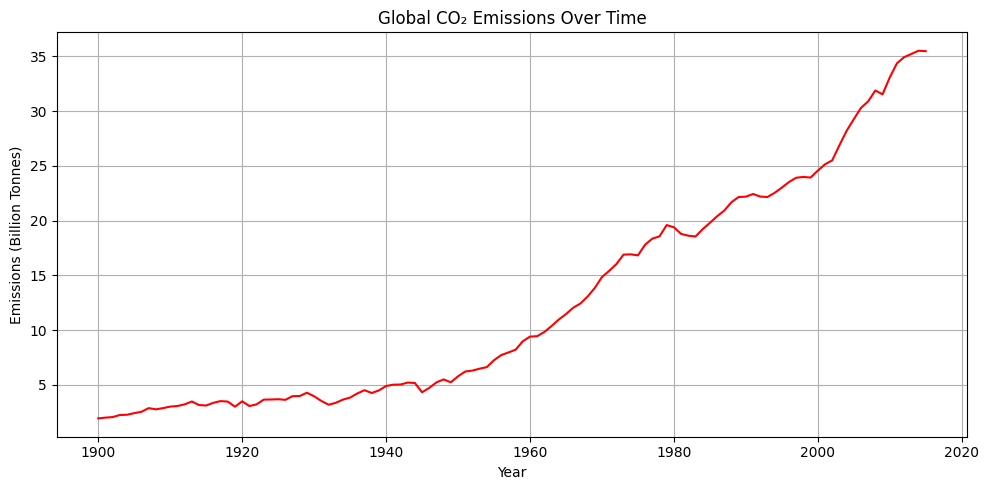

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(merged['Year'], merged['CO2_Emissions'] / 1e9, color='red')
plt.title("Global CO₂ Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("Emissions (Billion Tonnes)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Global Sea Level Rise Over Time

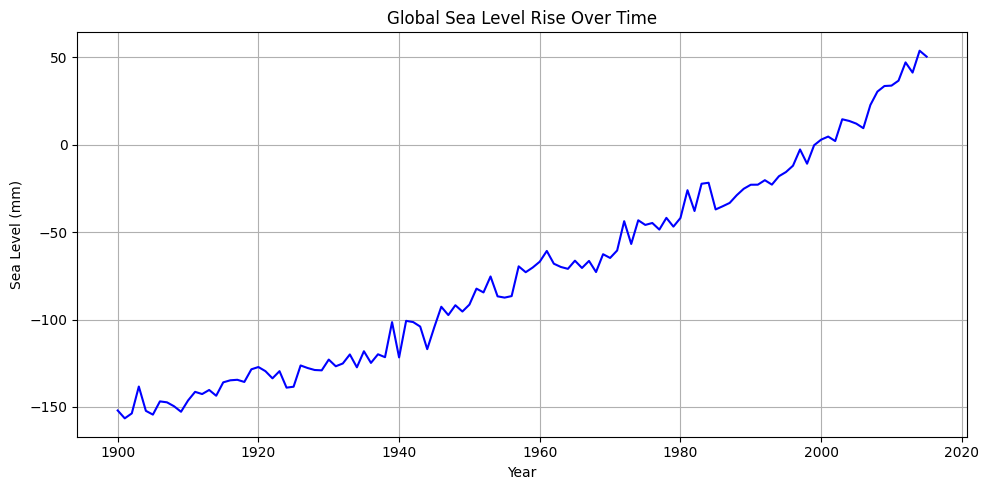

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(merged['Year'], merged['Sea_Level'], color='blue')
plt.title("Global Sea Level Rise Over Time")
plt.xlabel("Year")
plt.ylabel("Sea Level (mm)")
plt.grid(True)
plt.tight_layout()
plt.savefig("sea_level_rise_plot.png")  # لحفظ الصورة
plt.show()

# CO₂ vs Temp — Bubble Size = Sea Level

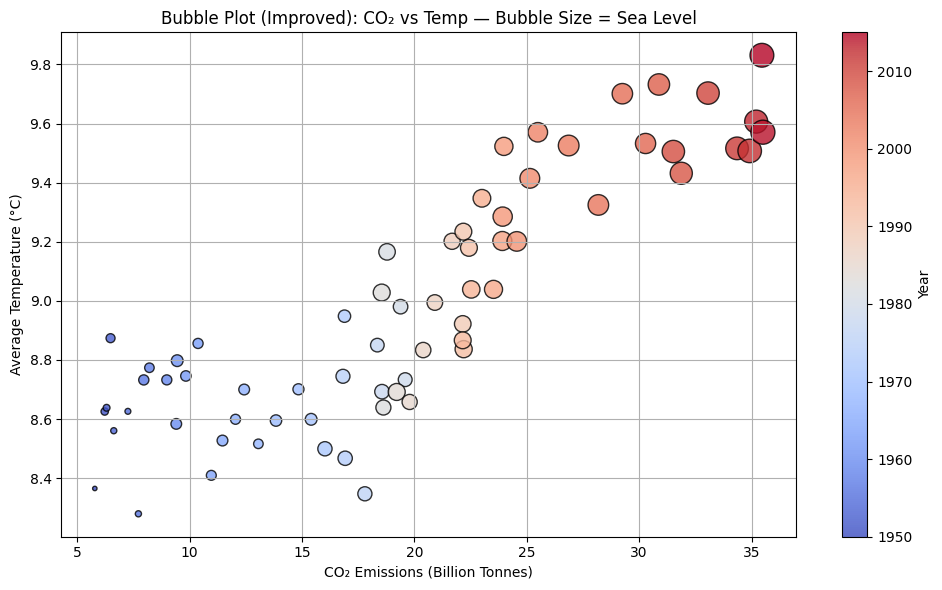

In [ ]:
import matplotlib.pyplot as plt

# فلترة البيانات بعد 1950 فقط
df_bubble = merged[merged['Year'] >= 1950].copy()

# رسم الفقاعات
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    df_bubble['CO2_Emissions'] / 1e9,                      # المحور X: CO2 بالمليار طن
    df_bubble['AverageTemperature'],                       # المحور Y: الحرارة
    s=(df_bubble['Sea_Level'] - df_bubble['Sea_Level'].min()) * 2 + 10,  # حجم الفقاعة (مقياس محسن)
    c=df_bubble['Year'], cmap='coolwarm',                  # لون الفقاعة حسب السنة
    alpha=0.8, edgecolors='k'
)

# إعدادات المحاور والعنوان
plt.xlabel("CO₂ Emissions (Billion Tonnes)")
plt.ylabel("Average Temperature (°C)")
plt.title("Bubble Plot (Improved): CO₂ vs Temp — Bubble Size = Sea Level")

# شريط الألوان
cbar = plt.colorbar(scatter)
cbar.set_label("Year")

# حفظ الصورة (اختياري)
plt.grid(True)
plt.tight_layout()
plt.savefig("bubble_plot_better.png")
plt.show()